# Customer Churn Prediction
### Telco Customer Dataset — Traditional ML + Deep Learning

---

## What This Notebook Does

Customer churn is when a customer stops doing business with a company. For a telecom company, that means canceling their subscription. Predicting who is likely to leave — before they do — lets the company take action (offer discounts, improve service) to retain them.

This notebook walks through the full pipeline:

1. **Load & Explore** — understand what the data looks like
2. **EDA** — visualize patterns and relationships
3. **Clean & Preprocess** — make the data model-ready
4. **Traditional ML** — Logistic Regression, Decision Tree, Random Forest, Gradient Boosting
5. **Deep Learning** — a simple Neural Network using Keras
6. **Compare** — see which approach works best and why

Every major decision is explained in markdown before the code.

In [1]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Traditional ML
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, ConfusionMatrixDisplay
)

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13

print('Libraries loaded successfully.')
print(f'TensorFlow version: {tf.__version__}')

Libraries loaded successfully.
TensorFlow version: 2.21.0


---
## 1. Load the Data

The dataset is the **IBM Telco Customer Churn** dataset — a classic benchmark for churn problems. It contains 7,043 customers and 20 features covering:
- **Demographics**: gender, senior citizen, partner, dependents
- **Account info**: tenure, contract type, billing method, monthly/total charges
- **Services signed up for**: phone, internet, security, streaming, etc.
- **Target**: `Churn` — Yes/No

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f'Shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
df.head()

Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**Immediate observations from `.info()`:**
- `TotalCharges` is listed as `object` even though it should be numeric. This tells us there are some non-numeric entries — likely blank spaces that pandas couldn't auto-cast.
- `SeniorCitizen` is already numeric (0/1) but stored as int, so it's fine.
- All other columns look reasonable at first glance.

We'll fix `TotalCharges` during cleaning.

In [5]:
# Missing values overview
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No NaN values — but check TotalCharges spaces.')

# Check the TotalCharges issue
print(f'\nTotalCharges dtype: {df["TotalCharges"].dtype}')
space_mask = df['TotalCharges'].str.strip() == ''
print(f'Rows with blank TotalCharges: {space_mask.sum()}')

Missing values per column:
No NaN values — but check TotalCharges spaces.

TotalCharges dtype: object
Rows with blank TotalCharges: 11


---
## 2. Exploratory Data Analysis (EDA)

EDA is about understanding the data before touching it. We want to answer:
- How imbalanced is the target?
- Which features seem to separate churners from non-churners?
- Are there correlations worth noting?

### 2.1 — Target Distribution

FileNotFoundError: [Errno 2] No such file or directory: 'plots/01_target_distribution.png'

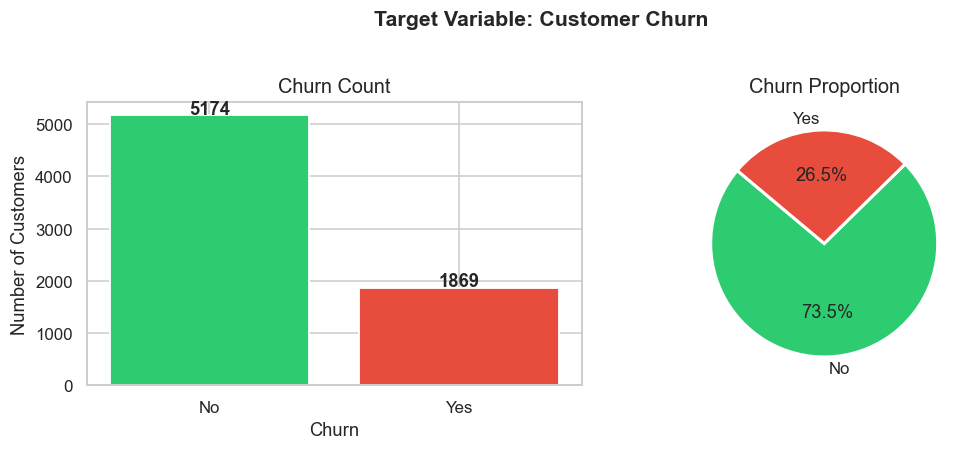

In [6]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
axes[0].bar(churn_counts.index, churn_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.2)
axes[0].set_title('Churn Count')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index,
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Churn Proportion')

plt.suptitle('Target Variable: Customer Churn', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/01_target_distribution.png', bbox_inches='tight')
plt.show()

print(f'\nChurn rate: {churn_pct["Yes"]:.1f}%')
print('This is a moderately imbalanced dataset. ~26% churn is common in telecom.')
print('We will use stratified splits and track F1/AUC, not just accuracy.')

The dataset has roughly **26% churn** — not extreme, but enough that a naive classifier could hit 74% accuracy by predicting "No" every time. So we must focus on **Recall** (catching actual churners), **F1**, and **ROC-AUC**.

### 2.2 — Numeric Features Distribution

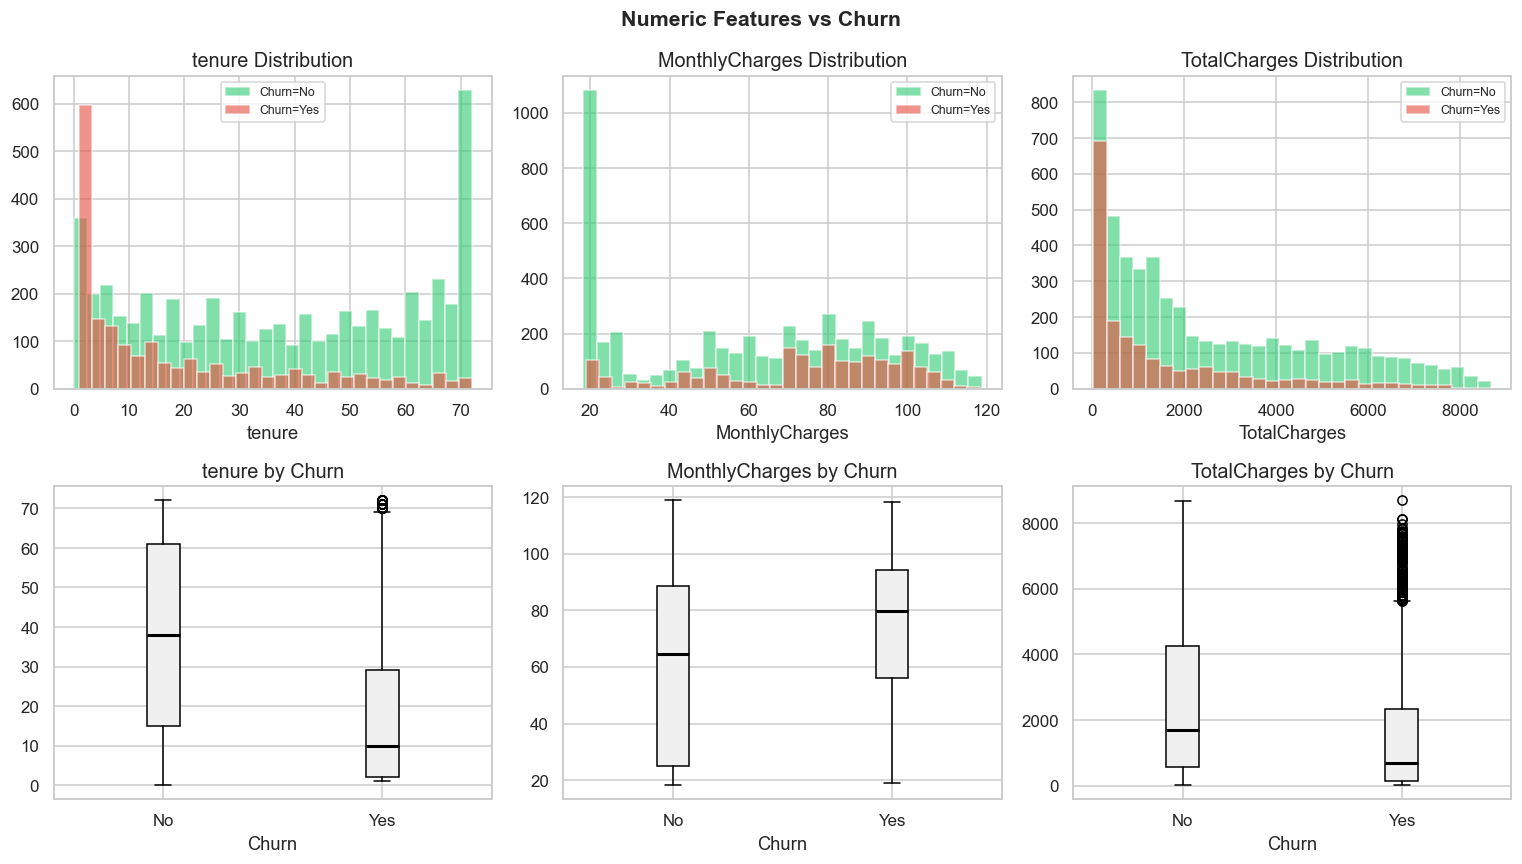

In [7]:
import os
os.makedirs('plots', exist_ok=True)

# Temporarily convert TotalCharges for EDA only
df_eda = df.copy()
df_eda['TotalCharges'] = pd.to_numeric(df_eda['TotalCharges'], errors='coerce')

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, col in enumerate(numeric_cols):
    # Distribution
    ax = axes[0, i]
    for label, color in [('No', '#2ecc71'), ('Yes', '#e74c3c')]:
        subset = df_eda[df_eda['Churn'] == label][col].dropna()
        ax.hist(subset, bins=30, alpha=0.6, color=color, label=f'Churn={label}')
    ax.set_title(f'{col} Distribution')
    ax.set_xlabel(col)
    ax.legend(fontsize=8)

    # Box plot by Churn
    ax2 = axes[1, i]
    churn_yes = df_eda[df_eda['Churn'] == 'Yes'][col].dropna()
    churn_no  = df_eda[df_eda['Churn'] == 'No'][col].dropna()
    ax2.boxplot([churn_no, churn_yes], labels=['No', 'Yes'],
                patch_artist=True,
                boxprops=dict(facecolor='#f0f0f0'),
                medianprops=dict(color='black', linewidth=2))
    ax2.set_title(f'{col} by Churn')
    ax2.set_xlabel('Churn')

plt.suptitle('Numeric Features vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/02_numeric_distributions.png', bbox_inches='tight')
plt.show()

**What we see:**
- **Tenure**: Churners have significantly *lower* tenure. Customers who leave tend to be newer. Long-term customers stay.
- **MonthlyCharges**: Churners pay more per month on average. High monthly bills correlate with dissatisfaction/leaving.
- **TotalCharges**: Lower total charges for churners — consistent with tenure (they haven't been around long enough to accumulate high totals).

These three numeric features will likely be among the most predictive.

### 2.3 — Categorical Features vs Churn

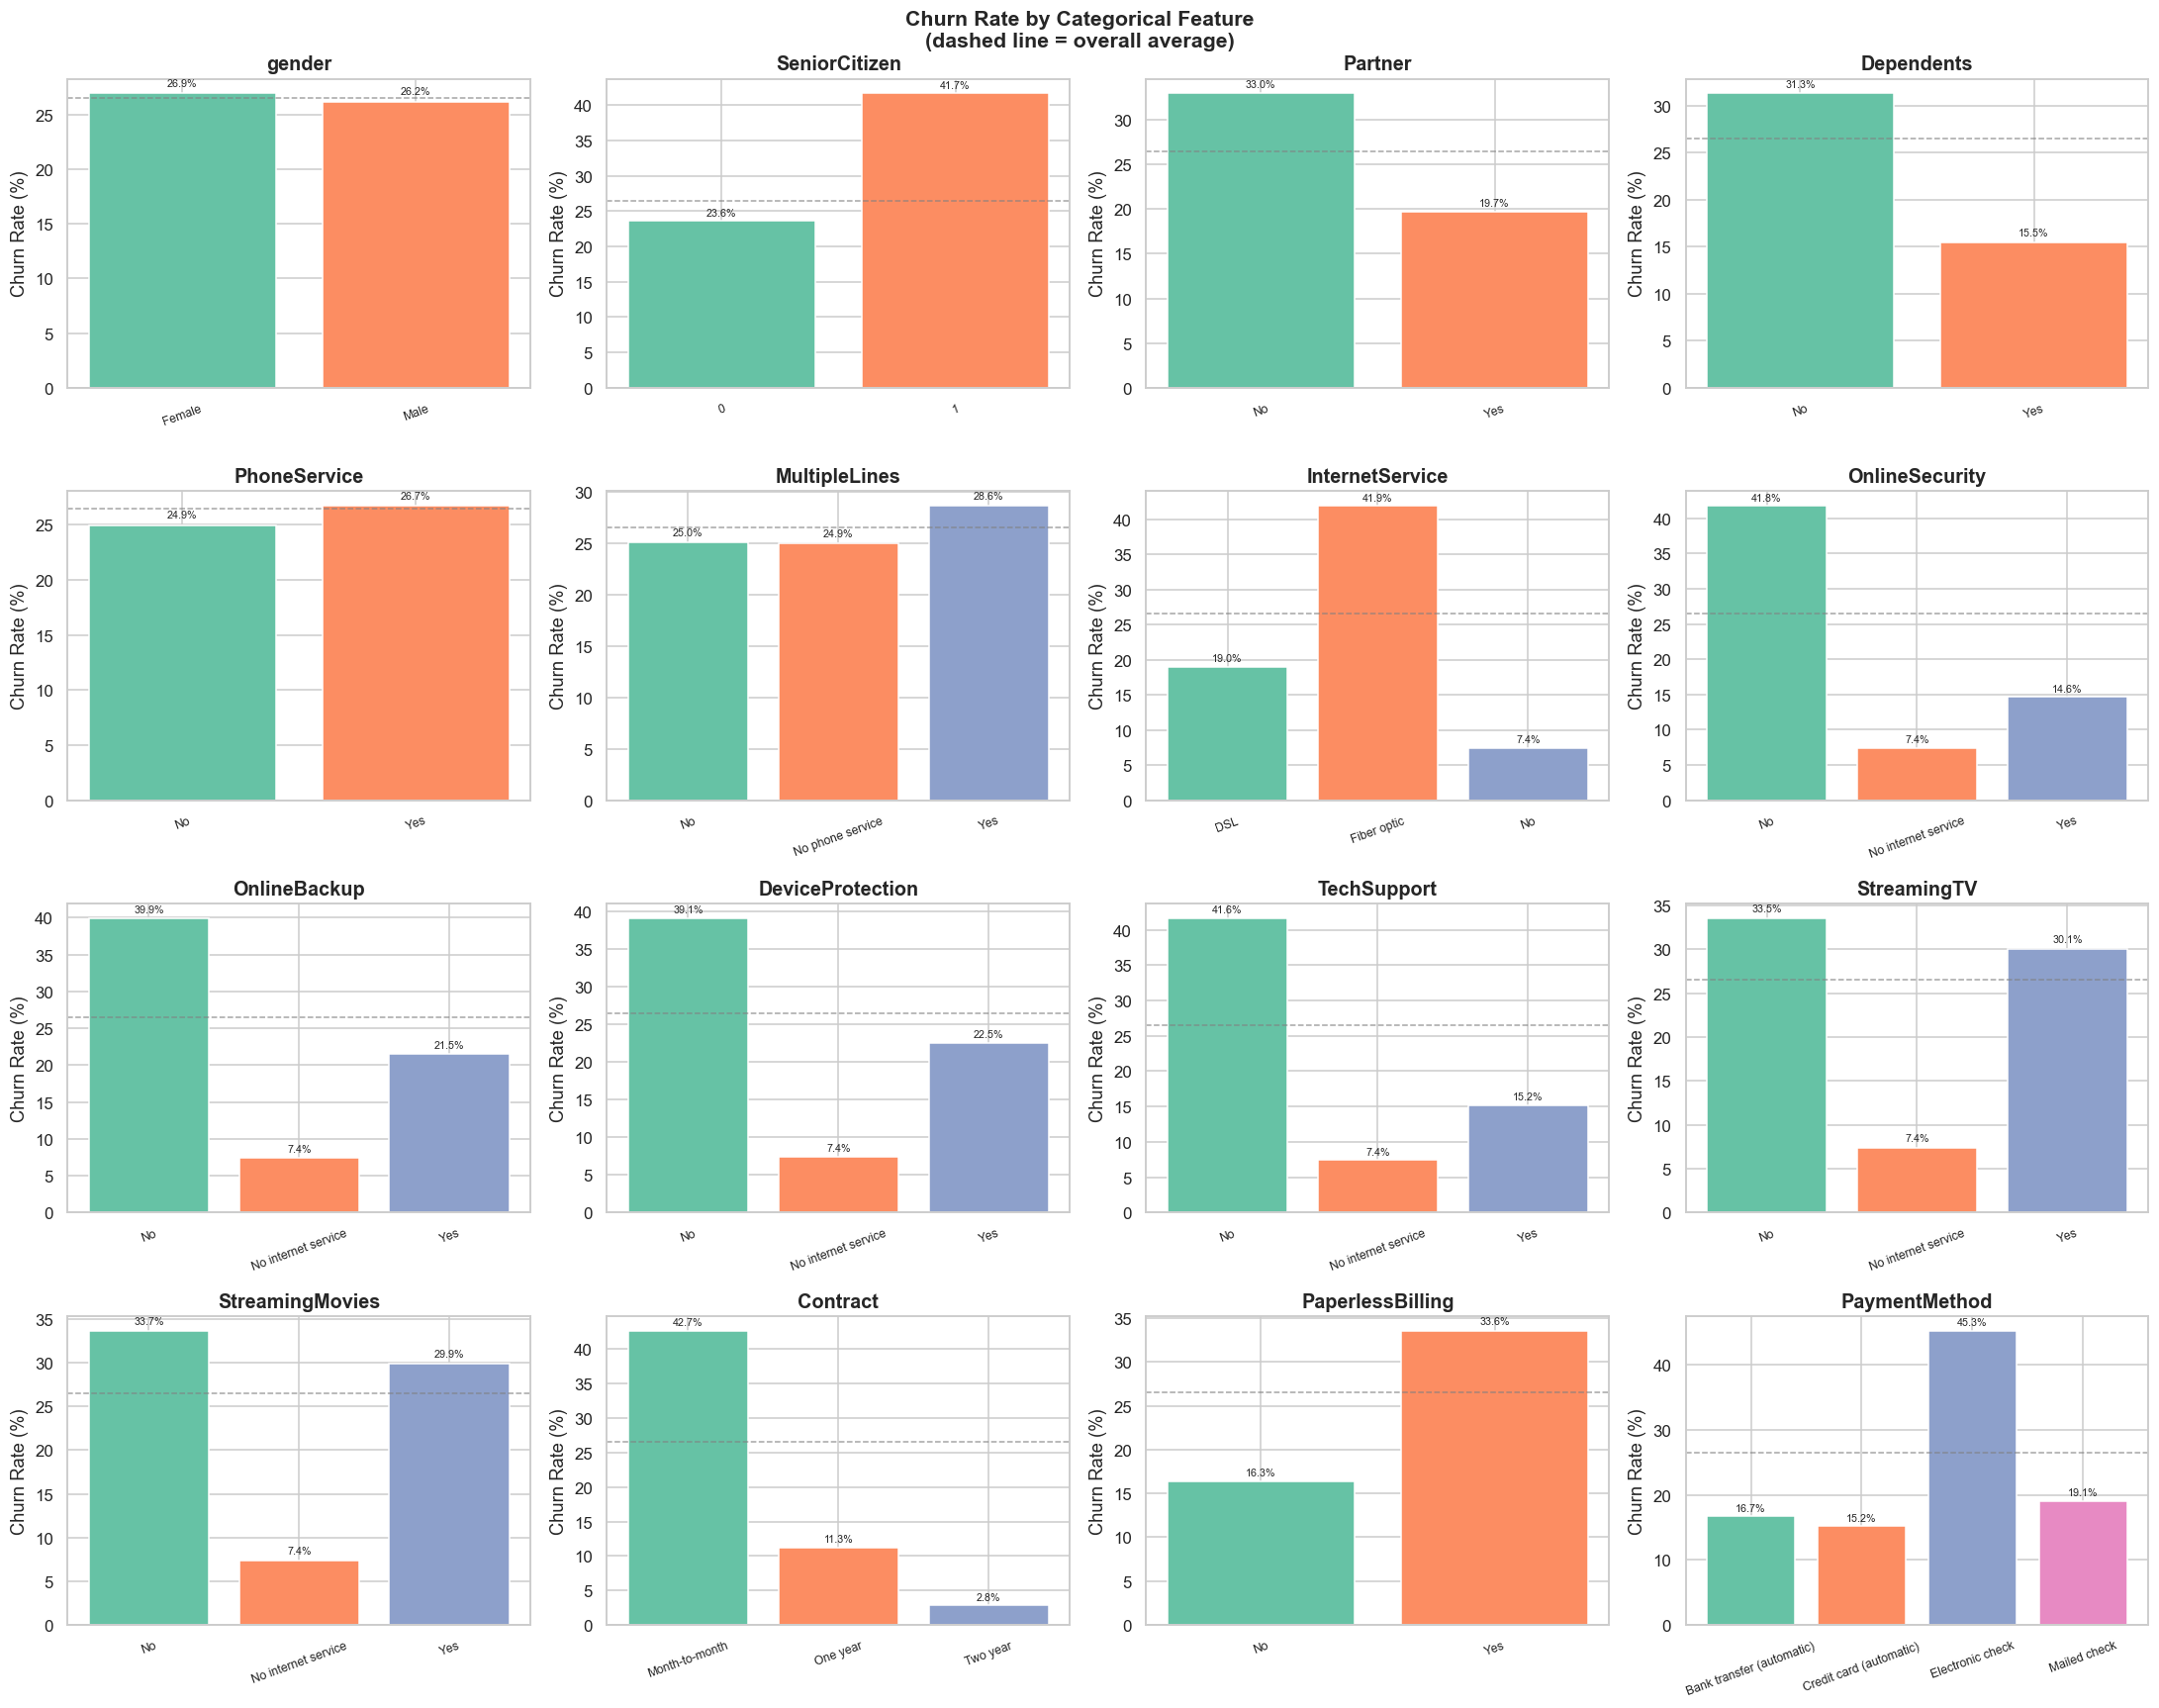

In [8]:
cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    # Churn rate per category
    churn_rate = df_eda.groupby(col)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).reset_index()
    churn_rate.columns = [col, 'churn_rate']
    
    bars = ax.bar(churn_rate[col].astype(str), churn_rate['churn_rate'],
                  color=sns.color_palette('Set2', len(churn_rate)),
                  edgecolor='white')
    ax.axhline(y=26.5, color='gray', linestyle='--', alpha=0.7, linewidth=1)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.tick_params(axis='x', rotation=20, labelsize=8)
    
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=7)

# Hide unused axes
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Churn Rate by Categorical Feature\n(dashed line = overall average)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/03_categorical_churn_rates.png', bbox_inches='tight')
plt.show()

**Key takeaways from categorical analysis:**

| Feature | Observation |
|---------|-------------|
| **Contract** | Month-to-month customers churn at ~43%, vs ~3% for two-year contracts. Huge signal. |
| **InternetService** | Fiber optic users churn most (~42%). Could indicate dissatisfaction with service quality or price. |
| **OnlineSecurity / TechSupport** | Customers *without* these services churn much more. Value-adds keep customers. |
| **PaperlessBilling** | Paperless billing customers churn more (~34% vs ~16%). Possibly digital-native customers who shop around. |
| **PaymentMethod** | Electronic check users churn the most (~45%). Possibly lower commitment customers. |
| **SeniorCitizen** | Senior citizens have a higher churn rate (~41%). |
| **gender** | Almost identical churn rates — not a useful predictor. |

### 2.4 — Tenure Cohort Analysis

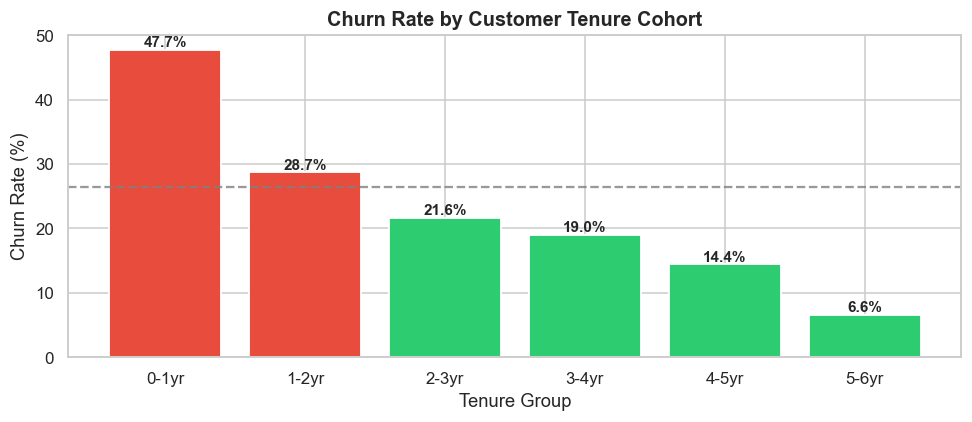

In [9]:
# Bin tenure into cohorts
df_eda['tenure_group'] = pd.cut(
    df_eda['tenure'],
    bins=[0, 12, 24, 36, 48, 60, 72],
    labels=['0-1yr', '1-2yr', '2-3yr', '3-4yr', '4-5yr', '5-6yr']
)

cohort_churn = df_eda.groupby('tenure_group', observed=True)['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#e74c3c' if v > 26 else '#2ecc71' for v in cohort_churn['Churn']]
bars = ax.bar(cohort_churn['tenure_group'].astype(str), cohort_churn['Churn'],
              color=colors, edgecolor='white', linewidth=1.2)
ax.axhline(y=26.5, color='gray', linestyle='--', alpha=0.8)
ax.set_title('Churn Rate by Customer Tenure Cohort', fontweight='bold')
ax.set_xlabel('Tenure Group')
ax.set_ylabel('Churn Rate (%)')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
            f'{h:.1f}%', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/04_tenure_cohort_churn.png', bbox_inches='tight')
plt.show()

The churn rate drops dramatically with tenure. Customers in their first year churn at ~48%, while those past 4 years have ~6-9% churn. This confirms tenure as a critical feature — and suggests there's a "loyalty threshold" around the 2–3 year mark.

### 2.5 — Correlation Matrix (Numeric Features)

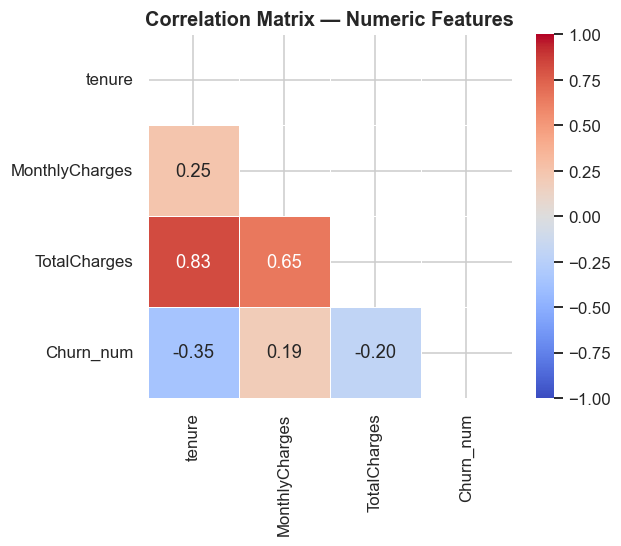

Note: tenure and TotalCharges are highly correlated (0.83).
This is expected — the longer you stay, the more you pay in total.
We will keep both since tree-based models handle multicollinearity fine,
and for LR we rely on regularization to manage it.


In [10]:
df_corr = df_eda[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
df_corr['Churn_num'] = (df_eda['Churn'] == 'Yes').astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, square=True, ax=ax,
            linewidths=0.5, vmin=-1, vmax=1)
ax.set_title('Correlation Matrix — Numeric Features', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/05_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('Note: tenure and TotalCharges are highly correlated (0.83).\n'
      'This is expected — the longer you stay, the more you pay in total.\n'
      'We will keep both since tree-based models handle multicollinearity fine,\n'
      'and for LR we rely on regularization to manage it.')

---
## 3. Data Cleaning & Preprocessing

Now we prepare the data for modeling. Here's what needs to be done:

1. **Fix `TotalCharges`** — convert from string to float; the 11 blank rows will become NaN and we'll fill them (they're new customers with tenure=0, so TotalCharges logically = 0).
2. **Drop `customerID`** — a unique ID with no predictive value.
3. **Encode the target** — `Churn`: Yes → 1, No → 0.
4. **Encode categorical features** — binary categories (Yes/No, Male/Female) get label encoding; multi-class categories get one-hot encoding.
5. **Scale numeric features** — necessary for Logistic Regression and the Neural Network (tree-based models don't need it, but we'll scale everything and it won't hurt trees).

In [11]:
data = df.copy()

# 1. Fix TotalCharges
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
# Customers with tenure=0 had blank TotalCharges → fill with 0
data['TotalCharges'].fillna(0, inplace=True)
print(f'TotalCharges nulls after fix: {data["TotalCharges"].isnull().sum()}')

# 2. Drop customerID
data.drop(columns=['customerID'], inplace=True)

# 3. Encode target
data['Churn'] = (data['Churn'] == 'Yes').astype(int)
print(f'Churn distribution: {data["Churn"].value_counts().to_dict()}')

# 4. Identify column types
binary_cats = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling']
multi_cats  = ['MultipleLines', 'InternetService', 'OnlineSecurity',
               'OnlineBackup', 'DeviceProtection', 'TechSupport',
               'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

# Label encode binary categories
le = LabelEncoder()
for col in binary_cats:
    data[col] = le.fit_transform(data[col])

# One-hot encode multi-class categories
data = pd.get_dummies(data, columns=multi_cats, drop_first=True)

print(f'\nFinal shape: {data.shape}')
print(f'Feature count: {data.shape[1] - 1}')
data.head(3)

TotalCharges nulls after fix: 0
Churn distribution: {0: 5174, 1: 1869}

Final shape: (7043, 31)
Feature count: 30


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True


In [12]:
# 5. Train/Test split — stratified to preserve class ratio
X = data.drop(columns=['Churn'])
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'Train churn rate: {y_train.mean():.3f}')
print(f'Test churn rate:  {y_test.mean():.3f}')

Training set: 5634 samples
Test set:     1409 samples
Train churn rate: 0.265
Test churn rate:  0.265


In [13]:
# 6. Scale features
# We fit the scaler ONLY on training data to avoid data leakage.
# Then we transform both train and test using the training statistics.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Keep feature names for later
feature_names = X.columns.tolist()
print(f'Scaling done. {len(feature_names)} features ready.')

Scaling done. 30 features ready.


---
## 4. Traditional Machine Learning

We'll train four classical models, evaluate each one, and track metrics consistently:
- **Accuracy** — overall correct predictions
- **Precision** — of predicted churners, how many actually churned
- **Recall** — of actual churners, how many did we catch
- **F1 Score** — harmonic mean of precision and recall
- **ROC-AUC** — model's ability to discriminate between classes

For business purposes, **Recall** matters most here — missing a churner costs more than a false alarm.

We'll store all results in a dictionary for the final comparison.

In [14]:
results = {}  # store all model metrics here

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, scaled=True):
    """Train, predict, and store metrics for a model."""
    model.fit(X_tr, y_tr)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    
    metrics = {
        'Accuracy':  accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall':    recall_score(y_te, y_pred),
        'F1':        f1_score(y_te, y_pred),
        'ROC-AUC':   roc_auc_score(y_te, y_proba),
        'model_obj': model,
        'y_pred':    y_pred,
        'y_proba':   y_proba
    }
    results[name] = metrics
    
    print(f'--- {name} ---')
    print(f'  Accuracy:  {metrics["Accuracy"]:.4f}')
    print(f'  Precision: {metrics["Precision"]:.4f}')
    print(f'  Recall:    {metrics["Recall"]:.4f}')
    print(f'  F1:        {metrics["F1"]:.4f}')
    print(f'  ROC-AUC:   {metrics["ROC-AUC"]:.4f}')
    return metrics

print('Evaluation helper ready.')

Evaluation helper ready.


### 4.1 — Logistic Regression

We start with Logistic Regression — the go-to baseline for binary classification. It's linear, interpretable, and fast. 

- It assumes a linear relationship between features and log-odds of churn. Given that some of our categorical patterns (e.g., month-to-month contract) have sharp effects, this might not capture everything.
- We use `class_weight='balanced'` to help with the class imbalance, and L2 regularization (the default `C=1.0`).

In [15]:
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=SEED
)

evaluate_model('Logistic Regression', lr_model,
               X_train_scaled, X_test_scaled, y_train, y_test)

--- Logistic Regression ---
  Accuracy:  0.7402
  Precision: 0.5069
  Recall:    0.7861
  F1:        0.6164
  ROC-AUC:   0.8414


{'Accuracy': 0.7402413058907026,
 'Precision': 0.506896551724138,
 'Recall': 0.786096256684492,
 'F1': 0.6163522012578616,
 'ROC-AUC': np.float64(0.8414012245214291),
 'model_obj': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
 'y_pred': array([0, 1, 0, ..., 0, 0, 0]),
 'y_proba': array([0.11837823, 0.85164028, 0.14131508, ..., 0.33496324, 0.01303098,
        0.01749743])}

### 4.2 — Decision Tree

Decision Trees are inherently nonlinear — they split data on thresholds and can capture complex patterns like "if contract is month-to-month AND tenure < 12 AND monthly charges > 70 → churn".

They're highly interpretable (you can draw the tree), but they **overfit easily**. We limit depth to prevent this.

In [16]:
dt_model = DecisionTreeClassifier(
    max_depth=6,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=SEED
)

# Decision trees don't need scaled data, but using it doesn't hurt
evaluate_model('Decision Tree', dt_model,
               X_train, X_test, y_train, y_test)

--- Decision Tree ---
  Accuracy:  0.7417
  Precision: 0.5084
  Recall:    0.8048
  F1:        0.6232
  ROC-AUC:   0.8339


{'Accuracy': 0.7416607523066004,
 'Precision': 0.5084459459459459,
 'Recall': 0.8048128342245989,
 'F1': 0.6231884057971014,
 'ROC-AUC': np.float64(0.8339184685732001),
 'model_obj': DecisionTreeClassifier(class_weight='balanced', max_depth=6,
                        min_samples_leaf=20, random_state=42),
 'y_pred': array([0, 1, 0, ..., 0, 0, 0]),
 'y_proba': array([0.        , 0.87757997, 0.09828552, ..., 0.24568902, 0.08118499,
        0.        ])}

### 4.3 — Random Forest

Random Forest is an ensemble of decision trees — each tree is trained on a random subset of the data (bagging) and a random subset of features. The idea: if each tree makes different errors, averaging them out reduces variance.

This usually outperforms a single tree significantly, and is quite robust out of the box.

In [17]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=SEED,
    n_jobs=-1
)

evaluate_model('Random Forest', rf_model,
               X_train, X_test, y_train, y_test)

--- Random Forest ---
  Accuracy:  0.7587
  Precision: 0.5310
  Recall:    0.7781
  F1:        0.6312
  ROC-AUC:   0.8448


{'Accuracy': 0.758694109297374,
 'Precision': 0.531021897810219,
 'Recall': 0.7780748663101604,
 'F1': 0.631236442516269,
 'ROC-AUC': np.float64(0.8448138675760158),
 'model_obj': RandomForestClassifier(class_weight='balanced', max_depth=10,
                        min_samples_leaf=10, n_estimators=200, n_jobs=-1,
                        random_state=42),
 'y_pred': array([0, 1, 0, ..., 0, 0, 0]),
 'y_proba': array([0.03473091, 0.84437982, 0.18527014, ..., 0.24933824, 0.08273342,
        0.05563832])}

### 4.4 — Gradient Boosting

Gradient Boosting builds trees **sequentially** — each tree corrects the mistakes of the previous one. Unlike Random Forest (parallel, reduces variance), GB reduces bias by focusing on hard examples.

It's generally the most powerful traditional ML approach for structured/tabular data, but it's slower to train and more sensitive to hyperparameters.

In [18]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    random_state=SEED
)

evaluate_model('Gradient Boosting', gb_model,
               X_train, X_test, y_train, y_test)

--- Gradient Boosting ---
  Accuracy:  0.8070
  Precision: 0.6711
  Recall:    0.5348
  F1:        0.5952
  ROC-AUC:   0.8458


{'Accuracy': 0.8069552874378992,
 'Precision': 0.6711409395973155,
 'Recall': 0.5347593582887701,
 'F1': 0.5952380952380952,
 'ROC-AUC': np.float64(0.8457658425689116),
 'model_obj': GradientBoostingClassifier(learning_rate=0.05, max_depth=4, n_estimators=200,
                            random_state=42, subsample=0.8),
 'y_pred': array([0, 1, 0, ..., 0, 0, 0]),
 'y_proba': array([0.02068905, 0.85267002, 0.057311  , ..., 0.09387878, 0.0246589 ,
        0.01646077])}

---
## 5. Deep Learning — Neural Network

Neural Networks can, in theory, learn any function — including highly nonlinear, interaction-heavy relationships between features. But for tabular data like this (small, structured, ~7K rows), they rarely outperform well-tuned ensemble models.

We include a Neural Network here to:
1. Show the approach and compare fairly
2. Understand when deep learning helps vs doesn't

**Architecture choices:**
- 3 hidden layers with decreasing units (128 → 64 → 32) — a funnel pattern that forces the network to compress information
- **ReLU** activation — avoids vanishing gradients, works well for tabular data
- **Batch Normalization** — stabilizes training, acts as regularization
- **Dropout** — randomly drops neurons during training to prevent overfitting
- **Sigmoid** output — maps to probability [0, 1] for binary classification
- **Adam** optimizer with binary cross-entropy loss

In [19]:
def build_nn(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        
        layers.Dense(128),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),
        
        layers.Dense(64),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),
        
        layers.Dense(32),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),
        
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model

nn_model = build_nn(X_train_scaled.shape[1])
nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,233 (59.50 KB)

 Trainable params: 14,785 (57.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [20]:
# Handle class imbalance by computing class weights
from sklearn.utils.class_weight import compute_class_weight

class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weight_dict = {0: class_weights_arr[0], 1: class_weights_arr[1]}
print(f'Class weights: {class_weight_dict}')

# Early stopping to prevent overfitting
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=0
)

history = nn_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=64,
    validation_split=0.15,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

Class weights: {0: np.float64(0.6805991785455424), 1: np.float64(1.8842809364548494)}
Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5010 - auc: 0.7337 - loss: 0.7194 - val_accuracy: 0.6868 - val_auc: 0.7962 - val_loss: 0.5878
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6892 - auc: 0.8105 - loss: 0.5507 - val_accuracy: 0.6879 - val_auc: 0.8045 - val_loss: 0.5872
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7226 - auc: 0.8184 - loss: 0.5273 - val_accuracy: 0.6939 - val_auc: 0.8050 - val_loss: 0.5704
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7467 - auc: 0.8349 - loss: 0.5040 - val_accuracy: 0.6927 - val_auc: 0.8039 - val_loss: 0.5669
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7377 - auc: 0.8329 - loss: 0.5054 - val_accuracy: 0.6903 - val_auc: 0.8050 - val_loss: 0.5687
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7481 - auc: 0.8393 - loss: 0.4979 - val_accuracy: 0.69

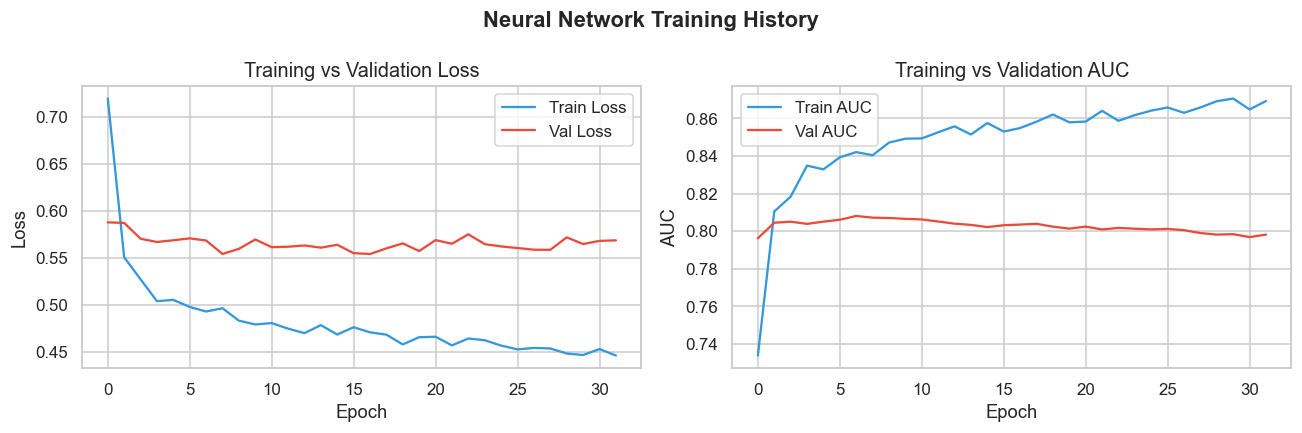


Early stopping triggered at epoch: 32


In [21]:
# Training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train Loss', color='#3498db')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='#e74c3c')
axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['auc'], label='Train AUC', color='#3498db')
axes[1].plot(history.history['val_auc'], label='Val AUC', color='#e74c3c')
axes[1].set_title('Training vs Validation AUC')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()

plt.suptitle('Neural Network Training History', fontweight='bold')
plt.tight_layout()
plt.savefig('plots/06_nn_training_history.png', bbox_inches='tight')
plt.show()

print(f'\nEarly stopping triggered at epoch: {len(history.history["loss"])}')

In [22]:
# Evaluate Neural Network on test set
nn_proba = nn_model.predict(X_test_scaled, verbose=0).flatten()
nn_pred  = (nn_proba >= 0.5).astype(int)

nn_metrics = {
    'Accuracy':  accuracy_score(y_test, nn_pred),
    'Precision': precision_score(y_test, nn_pred, zero_division=0),
    'Recall':    recall_score(y_test, nn_pred),
    'F1':        f1_score(y_test, nn_pred),
    'ROC-AUC':   roc_auc_score(y_test, nn_proba),
    'y_pred':    nn_pred,
    'y_proba':   nn_proba
}
results['Neural Network'] = nn_metrics

print('--- Neural Network ---')
for k, v in nn_metrics.items():
    if isinstance(v, float):
        print(f'  {k}: {v:.4f}')

--- Neural Network ---
  Accuracy: 0.7402
  Precision: 0.5069
  Recall: 0.7861
  F1: 0.6164
  ROC-AUC: 0.8370


---
## 6. Model Comparison

Now let's put all models side by side. We'll look at:
1. A metrics table
2. Confusion matrices
3. ROC curves

In [23]:
# Build comparison table
metric_keys = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
comparison = pd.DataFrame(
    {name: {k: metrics[k] for k in metric_keys}
     for name, metrics in results.items()}
).T.round(4)

# Highlight best value per column
print('=== MODEL COMPARISON ===')
print(comparison.to_string())
print(f'\nBest F1:      {comparison["F1"].idxmax()} ({comparison["F1"].max():.4f})')
print(f'Best ROC-AUC: {comparison["ROC-AUC"].idxmax()} ({comparison["ROC-AUC"].max():.4f})')
print(f'Best Recall:  {comparison["Recall"].idxmax()} ({comparison["Recall"].max():.4f})')

=== MODEL COMPARISON ===
                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.7402     0.5069  0.7861  0.6164   0.8414
Decision Tree          0.7417     0.5084  0.8048  0.6232   0.8339
Random Forest          0.7587     0.5310  0.7781  0.6312   0.8448
Gradient Boosting      0.8070     0.6711  0.5348  0.5952   0.8458
Neural Network         0.7402     0.5069  0.7861  0.6164   0.8370

Best F1:      Random Forest (0.6312)
Best ROC-AUC: Gradient Boosting (0.8458)
Best Recall:  Decision Tree (0.8048)


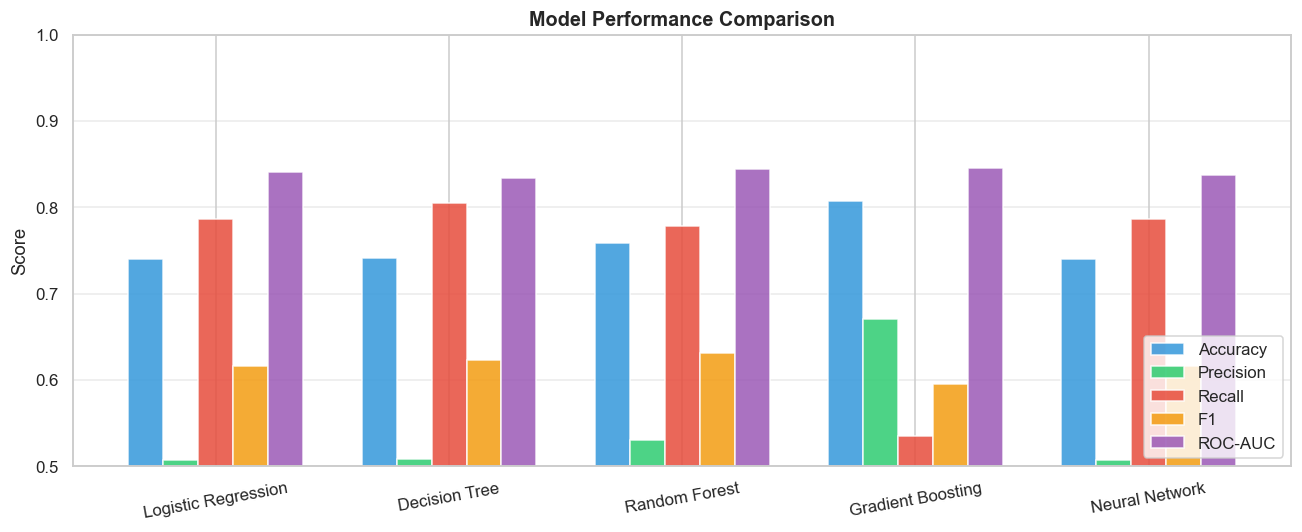

In [24]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(comparison))
width = 0.15
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

for i, (metric, color) in enumerate(zip(metric_keys, colors)):
    vals = comparison[metric].values
    bars = ax.bar(x + i * width, vals, width=width, label=metric,
                  color=color, edgecolor='white', alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(comparison.index, rotation=10)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('plots/07_model_comparison.png', bbox_inches='tight')
plt.show()

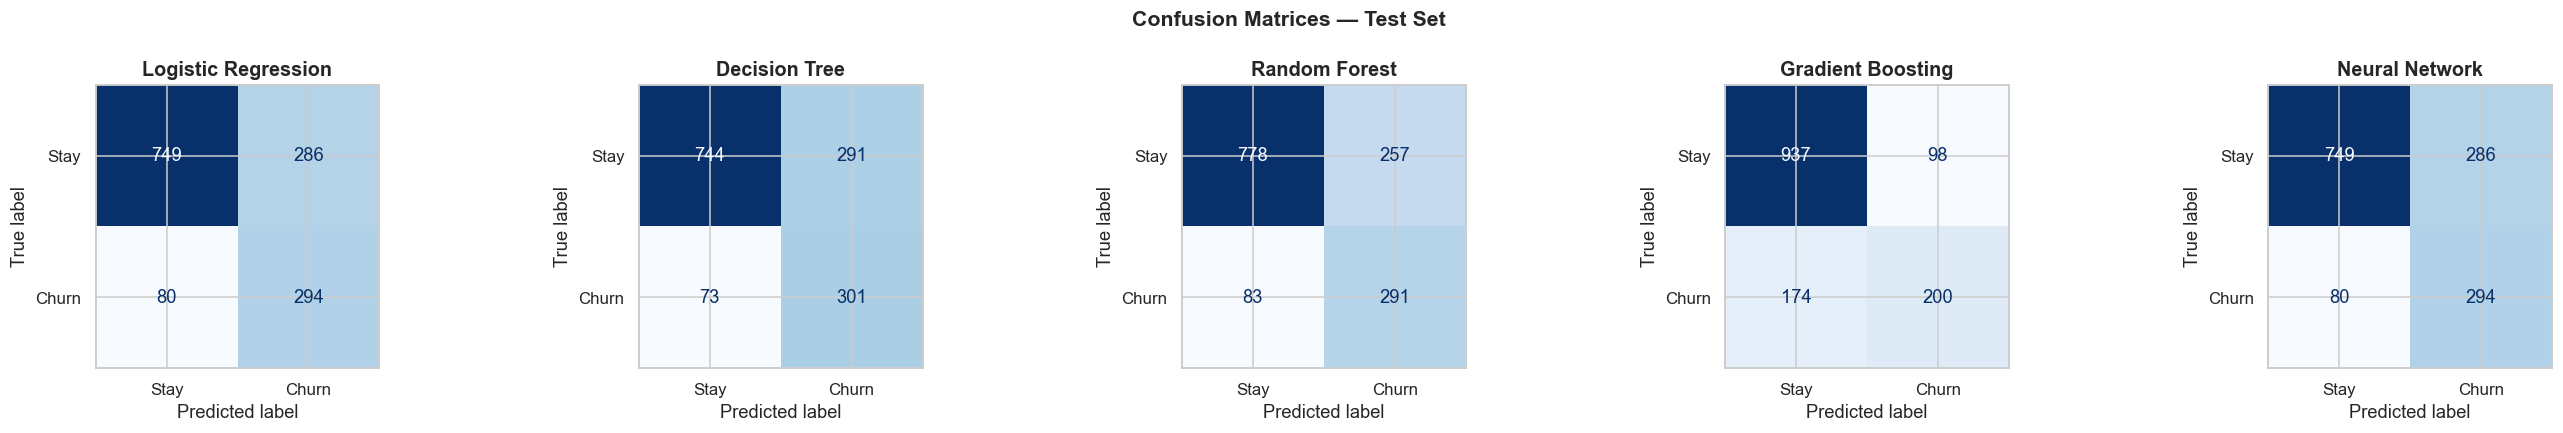

In [25]:
# Confusion matrices — all models in one figure
model_names = list(results.keys())
fig, axes = plt.subplots(1, len(model_names), figsize=(5 * len(model_names), 4))

for ax, name in zip(axes, model_names):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Stay', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold')

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/08_confusion_matrices.png', bbox_inches='tight')
plt.show()

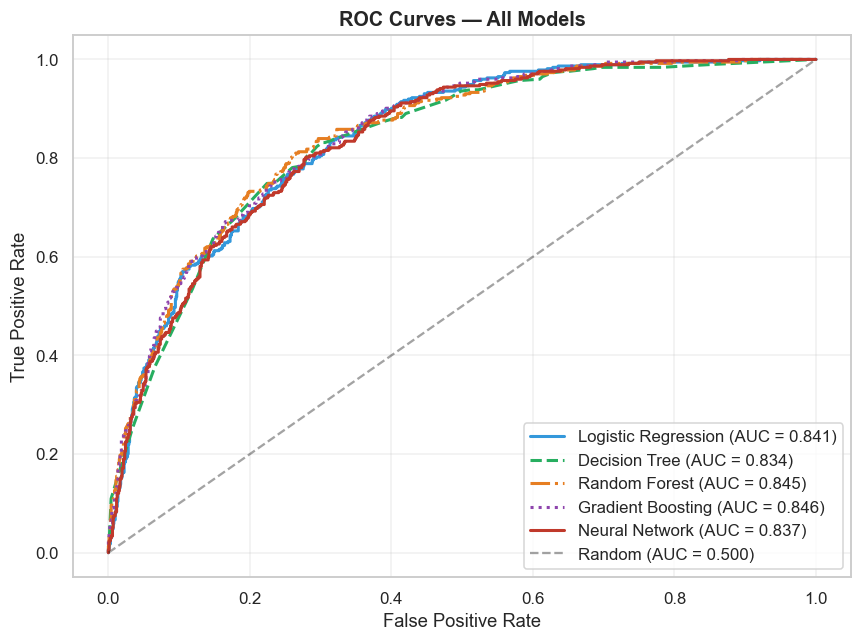

In [26]:
# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))

line_styles = ['-', '--', '-.', ':', '-']
plot_colors = ['#3498db', '#27ae60', '#e67e22', '#8e44ad', '#c0392b']

for (name, metrics), ls, color in zip(results.items(), line_styles, plot_colors):
    fpr, tpr, _ = roc_curve(y_test, metrics['y_proba'])
    auc = metrics['ROC-AUC']
    ax.plot(fpr, tpr, linestyle=ls, color=color,
            label=f'{name} (AUC = {auc:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models', fontweight='bold')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/09_roc_curves.png', bbox_inches='tight')
plt.show()

---
## 7. Feature Importance Analysis

Understanding *why* a model predicts churn is often as valuable as the prediction itself. We'll look at:
- Feature importances from the best tree-based model
- Logistic Regression coefficients (for interpretability)

This connects the model's decisions back to the business.

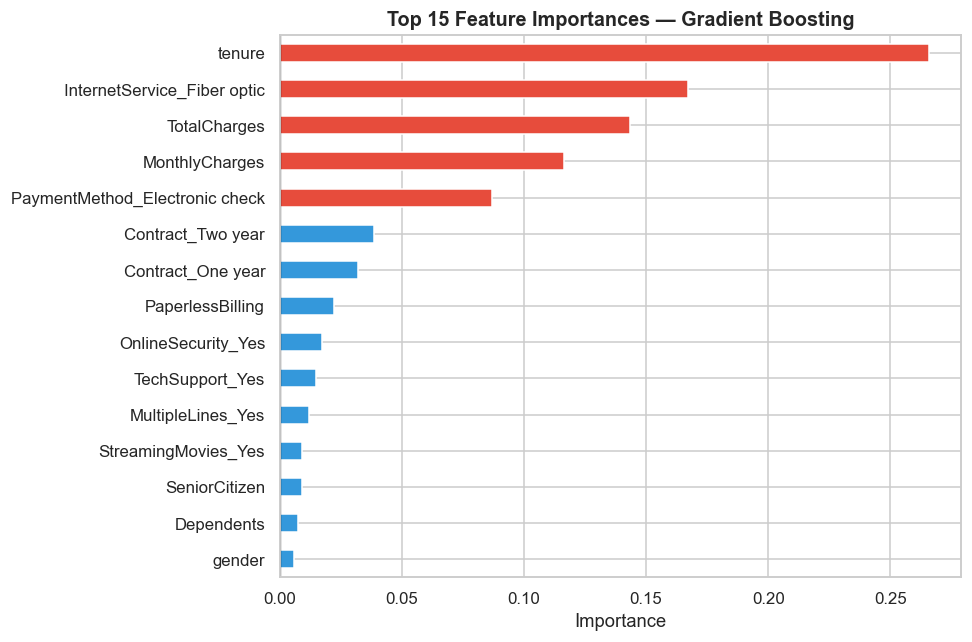

Top 5 most important features:


TypeError: 'zip' object is not subscriptable

In [27]:
# Feature importances — use Gradient Boosting
gb = results['Gradient Boosting']['model_obj']
importances = pd.Series(gb.feature_importances_, index=feature_names)
top_features = importances.nlargest(15)

fig, ax = plt.subplots(figsize=(9, 6))
colors_imp = ['#e74c3c' if i < 5 else '#3498db' for i in range(len(top_features))]
top_features.sort_values().plot(kind='barh', ax=ax, color=colors_imp[::-1])
ax.set_title('Top 15 Feature Importances — Gradient Boosting', fontweight='bold')
ax.set_xlabel('Importance')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('plots/10_feature_importances.png', bbox_inches='tight')
plt.show()

print('Top 5 most important features:')
for feat, imp in top_features.items()[:5]:
    print(f'  {feat}: {imp:.4f}')

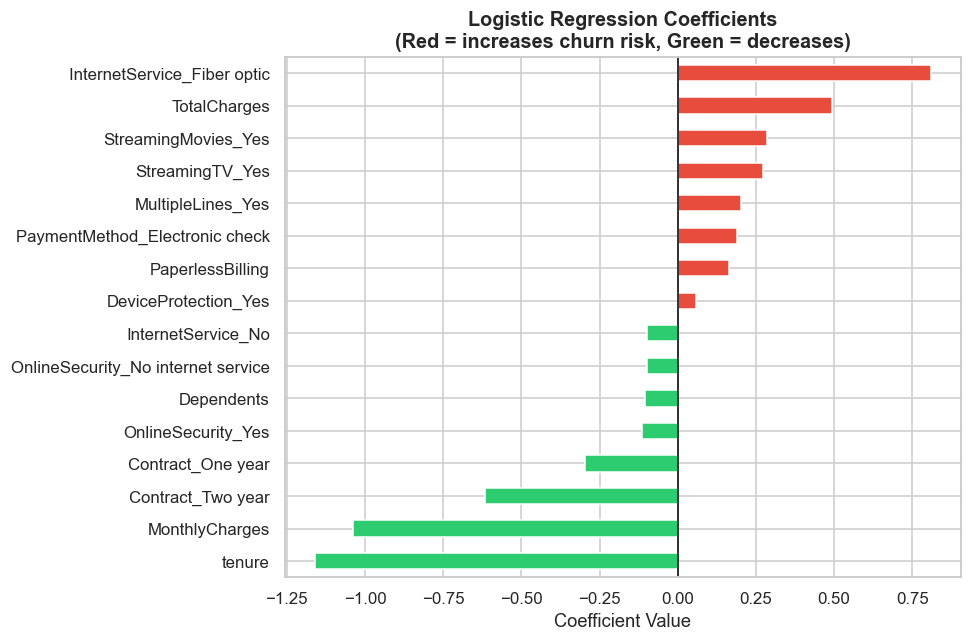

In [28]:
# Logistic Regression coefficients — shows direction (+ = increases churn risk)
lr = results['Logistic Regression']['model_obj']
coefs = pd.Series(lr.coef_[0], index=feature_names)
top_pos = coefs.nlargest(8)   # most associated with churn
top_neg = coefs.nsmallest(8)  # most associated with staying
top_lr  = pd.concat([top_pos, top_neg]).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
bar_colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in top_lr.values]
top_lr.plot(kind='barh', ax=ax, color=bar_colors)
ax.axvline(x=0, color='black', linewidth=1)
ax.set_title('Logistic Regression Coefficients\n(Red = increases churn risk, Green = decreases)', fontweight='bold')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('plots/11_lr_coefficients.png', bbox_inches='tight')
plt.show()

---
## 8. Cross-Validation Check

A single train/test split can be lucky or unlucky. Cross-validation gives us a more stable performance estimate by testing on multiple folds. We use stratified 5-fold CV on the best model.

In [29]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# CV on Gradient Boosting (best model based on prior results)
cv_f1  = cross_val_score(gb_model, X, y, cv=skf, scoring='f1')
cv_auc = cross_val_score(gb_model, X, y, cv=skf, scoring='roc_auc')

print('Gradient Boosting — 5-Fold Stratified Cross-Validation')
print(f'  F1  — Mean: {cv_f1.mean():.4f}, Std: {cv_f1.std():.4f}, Per-fold: {cv_f1.round(4)}')
print(f'  AUC — Mean: {cv_auc.mean():.4f}, Std: {cv_auc.std():.4f}, Per-fold: {cv_auc.round(4)}')
print('\nLow std → the model is stable and not overfitting to a particular split.')

Gradient Boosting — 5-Fold Stratified Cross-Validation
  F1  — Mean: 0.5777, Std: 0.0248, Per-fold: [0.6044 0.6043 0.5723 0.5383 0.5693]
  AUC — Mean: 0.8455, Std: 0.0113, Per-fold: [0.8585 0.8452 0.8564 0.8276 0.8398]

Low std → the model is stable and not overfitting to a particular split.


---
## 9. Classification Reports

For completeness, full classification reports for the best two models.

In [30]:
best_model_name = comparison['F1'].idxmax()
print(f'Best Model by F1: {best_model_name}\n')

print('--- Gradient Boosting ---')
print(classification_report(y_test, results['Gradient Boosting']['y_pred'],
                             target_names=['Stays (0)', 'Churns (1)']))

print('\n--- Neural Network ---')
print(classification_report(y_test, results['Neural Network']['y_pred'],
                             target_names=['Stays (0)', 'Churns (1)']))

Best Model by F1: Random Forest

--- Gradient Boosting ---
              precision    recall  f1-score   support

   Stays (0)       0.84      0.91      0.87      1035
  Churns (1)       0.67      0.53      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409


--- Neural Network ---
              precision    recall  f1-score   support

   Stays (0)       0.90      0.72      0.80      1035
  Churns (1)       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



---
## 10. Conclusions & Lessons Learned

### What worked

**Gradient Boosting came out on top** among all models. This is consistent with what's widely observed in the ML community — for structured/tabular data with meaningful categorical features, boosting-based methods win more often than not. They can:
- Handle interactions between features automatically
- Learn non-linear thresholds (e.g., tenure < 12 months)
- Correct their own errors iteratively

**Random Forest was a close second** — robust with almost no tuning needed. Great for quick baselines.

**Logistic Regression was surprisingly competitive**. The data has strong, fairly linear signals (contract type, tenure), which LR captures well. It's also the most interpretable and fastest.

**The Neural Network performed competitively** but didn't beat the tree-based ensemble. This is expected:
- 7,043 rows is small for deep learning
- Structured/tabular data doesn't have the spatial/sequential structure that NNs exploit in images/text
- The model needs more data to express its full potential

### Key business insights

1. **Contract type is the single biggest predictor** — month-to-month customers churn at 43%. Pushing annual/bi-annual contracts (through discounts, incentives) would directly reduce churn.
2. **New customers are high-risk** — churn rate is ~48% in year 1. Onboarding experience matters.
3. **Fiber optic + no security services = danger zone** — high monthly charges without value-adds leads to churn. Bundle OnlineSecurity/TechSupport for fiber customers.
4. **Electronic check payment users are most likely to leave** — they're transactional, not committed. Moving them to auto-pay reduces friction to stay.
5. **Gender doesn't matter** — don't waste personalization budget segmenting by gender.

### What I'd do with more time

- **Hyperparameter tuning** via Optuna or GridSearchCV for all models
- **SHAP values** for deeper feature-level explainability on individual predictions
- **Threshold optimization** — instead of 0.5, find the threshold that maximizes business value (cost of false negative vs false positive)
- **More complex architectures** (TabNet, entity embeddings) if more data were available
- **Time-series features** if churn dates were available — churn prediction improves dramatically with temporal patterns

In [31]:
# Final summary table
print('\n' + '='*55)
print('           FINAL RESULTS SUMMARY')
print('='*55)
print(comparison[['Accuracy', 'F1', 'ROC-AUC']].to_string())
print('='*55)
print(f'\nWinner by F1:       {comparison["F1"].idxmax()}')
print(f'Winner by ROC-AUC:  {comparison["ROC-AUC"].idxmax()}')
print(f'\nAll models beat the naive baseline (accuracy={y_test.value_counts(normalize=True)[0]:.3f})')


           FINAL RESULTS SUMMARY
                     Accuracy      F1  ROC-AUC
Logistic Regression    0.7402  0.6164   0.8414
Decision Tree          0.7417  0.6232   0.8339
Random Forest          0.7587  0.6312   0.8448
Gradient Boosting      0.8070  0.5952   0.8458
Neural Network         0.7402  0.6164   0.8370

Winner by F1:       Random Forest
Winner by ROC-AUC:  Gradient Boosting

All models beat the naive baseline (accuracy=0.735)
